### Steps

 0. Preprocess + EDA + Feature Selection
 1. Extract input and output cols
 2. Scale the values
 3. Train test split
 4. Train the model
 5. Evaluate the model/model selection
 6. Deploy the model

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

#### Preprocess + EDA + Feature Selection

In [5]:
df = pd.read_csv('C:\\Users\\M.LAPTOP\\Desktop\\New folder\\Data\\placement.csv')
df.head()

,Unnamed: 0,cgpa,iq,placement
0,0,6.8,123.0,1
1,1,5.9,106.0,0
2,2,5.3,121.0,0
3,3,7.4,132.0,1
4,4,5.8,142.0,0


In [6]:
df = df.iloc[:,1:]
df.head()

,cgpa,iq,placement
0,6.8,123.0,1
1,5.9,106.0,0
2,5.3,121.0,0
3,7.4,132.0,1
4,5.8,142.0,0


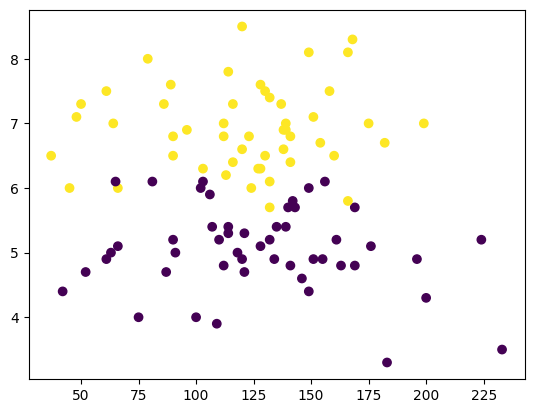

In [7]:
plt.scatter(df['iq'],df['cgpa'],c=df['placement'])

#### Extract input and output cols

In [8]:
x = df.iloc[:,:2]
x

,cgpa,iq
0,6.8,123.0
1,5.9,106.0
2,5.3,121.0
3,7.4,132.0
4,5.8,142.0
...,...,...
95,4.3,200.0
96,4.4,42.0
97,6.7,182.0
98,6.3,103.0


In [9]:
y = df.iloc[:,-1]
y

0     1
1     0
2     0
3     1
4     0
     ..
95    0
96    0
97    1
98    1
99    1
Name: placement, Length: 100, dtype: int64

#### Train test split

In [10]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.1)

In [11]:
x_train

,cgpa,iq
4,5.8,142.0
2,5.3,121.0
47,5.2,161.0
72,7.3,116.0
84,5.7,169.0
...,...,...
59,4.8,112.0
71,6.1,132.0
58,8.0,79.0
30,7.6,128.0


In [12]:
x_test

,cgpa,iq
97,6.7,182.0
34,4.8,163.0
83,7.5,130.0
20,6.6,120.0
36,5.7,140.0
51,4.8,141.0
89,4.9,151.0
28,5.2,90.0
45,6.0,66.0
63,6.3,128.0


In [13]:
y_test

97    1
34    0
83    1
20    1
36    0
51    0
89    0
28    0
45    1
63    1
Name: placement, dtype: int64

#### Scale the values

In [14]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

In [15]:
x_train = scaler.fit_transform(x_train)

In [16]:
x_train

array([[-0.17788792,  0.47631031],
       [-0.60826191, -0.04315102],
       [-0.69433671,  0.94629913],
       [ 1.11323406, -0.16683229],
       [-0.26396271,  1.14418916],
       [-0.52218711, -0.38945857],
       [-0.7804115 , -1.40364498],
       [-0.09181312, -0.41419483],
       [ 1.11323406, -1.79942504],
       [ 0.85500966,  0.40210155],
       [ 0.25248607,  0.1052665 ],
       [ 0.85500966, -1.45311749],
       [-1.46900989,  1.91101303],
       [-0.69433671, -0.31524981],
       [ 1.19930886,  0.22894777],
       [ 0.42463567, -2.12099634],
       [-0.9525611 , -1.52732625],
       [-0.8664863 , -1.47785374],
       [ 0.42463567,  0.17947526],
       [-1.1247107 , -1.74995254],
       [-0.52218711,  0.30315653],
       [ 1.28538365, -1.52732625],
       [ 1.11323406, -0.90891991],
       [ 0.85500966,  1.29260669],
       [-0.00573832, -0.51313984],
       [ 0.51071047,  0.37736529],
       [ 0.42463567, -0.80997489],
       [-0.7804115 ,  0.13000276],
       [-1.72723428,

In [17]:
x_test = scaler.transform(x_test)

In [18]:
x_test

array([[ 0.59678527,  1.46576046],
       [-1.0386359 ,  0.99577164],
       [ 1.28538365,  0.17947526],
       [ 0.51071047, -0.06788727],
       [-0.26396271,  0.4268378 ],
       [-1.0386359 ,  0.45157406],
       [-0.9525611 ,  0.6989366 ],
       [-0.69433671, -0.80997489],
       [-0.00573832, -1.40364498],
       [ 0.25248607,  0.13000276]])

#### Train the model

In [19]:
from sklearn.linear_model import LogisticRegression
clf = LogisticRegression()

In [20]:
clf.fit(x_train,y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [21]:
y_predict = clf.predict(x_test)

In [22]:
y_predict

array([1, 0, 1, 1, 0, 0, 0, 0, 0, 1])

In [23]:
y_test

97    1
34    0
83    1
20    1
36    0
51    0
89    0
28    0
45    1
63    1
Name: placement, dtype: int64

In [24]:
from sklearn.metrics import accuracy_score

In [25]:
accuracy_score(y_test,y_predict)

0.9

In [26]:
from mlxtend.plotting import plot_decision_regions


<Axes: >

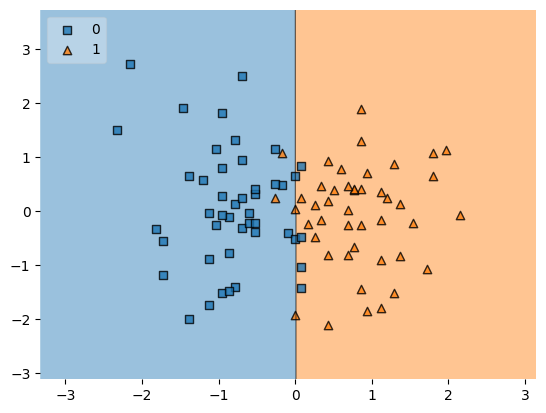

In [27]:
plot_decision_regions(x_train, y_train.values, clf=clf, legend=2)

#### Deploy the model

In [28]:
import pickle

In [29]:
pickle.dump(clf,open('model.pkl','wb'))